In [168]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
import GB84_eqs # import f as flux, rho_m,flux_2
import updraft_emmanuel
#from updraft_emmanuel import w_parcel 
import new_rainfall_scheme as nr
import top_outflow as outflow

## Loading the data

Choose the time interval for which the model is to be run.

In [741]:
#time to check
slice_str = "2024-07-01T00:00:00, 2024-07-16T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


Read the data which are to be used as inputs. The existing code uses a combined dataset from ERA5 surface values and ERA5 atmospheric profiles. The surface variables include the temperature, pressure, dew point temperature and vapor specific humidity and the profiles are of temperature,pressure and vapor specific humidity. Then, only the data corresponding to the desired time interval are selected.

In [742]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [743]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

In [744]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [745]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [746]:
rows = T_air.shape[0]
cols = T_air.shape[1]

Creating empty arrays (either of size (time,height) or (time)) for storing the model outputs. *temp_parcel* is the parcel temperature profile resulting by solving the thermodynamic equations implemented in the model, while *T_v_moist* and *q_v_parcel* are the resulting virtual temperature and moisture profiles of the parcel. *p_s*, *T_s* and *lcl_index* are the pressure, temperature and index at the LCL level. All the other arrays serve as the expansion of the current environmental profiles by 1 (time,height+1), so that the exact values of the meteorological variables at the LCL are stored. 

In [747]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


Implementing the model functions to calculate the temperature and humidity profiles.

1. Using the *profiles_and_cloud_heights.py*, the parcel temperature profile is calculated, as well as the LCL variables of interest.
2. Using the *interpolation_lcl.py*, all the parcel and environmental profiles are updated so that we have exact values for all the meteorological
   variables of interest at the LCL.
3. With *profiles_and_cloud_heights.py* parcel humidity and virtual temperature profiles are calculated. 

In [748]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'theta_l'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    #print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i,0],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

Calculate the environmental virtual temperature profiles

In [749]:
T_v_env = my_temp_new*(1+0.61*q_v_new)

### Cloud Heights

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [750]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

Finding the cloud top height and pressure and the resulting cloud depth, again by calling *profiles_and_cloud_heights.py*.

In [751]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [752]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))

for i in range(0,rows):
    print(i)
    if Z_c[i] <= 100:
        T_parcel_new[i] = temp_parcel[i]
        q_t_parcel_new[i] = q_v_new[i]
    else:
        entrainment_rate = 1/Z_c[i]     #Siebesma et al. (2003)
        T_parcel_new[i],q_t_parcel_new[i] = profiles.calculate_profiles_with_entrainment(T_s[i], T_d[i], my_temp_new[i], temp_parcel[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(lcl_index[i]), entrainment_rate, theta_type)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36


c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\new_model\physics_equations.py:36: RuntimeWarning: invalid value encountered in power
  np.exp(34.494 - 4924.99 / (T_C + 237.1)) / (T_C + 105) ** 1.57,


37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156


c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\scipy\optimize\_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\new_model\physics_equations.py:115: RuntimeWarning: invalid value encountered in power
  return theta * ((epsilon + qv) / (epsilon + qt))**poisson * (qv/qt)**(qt*R_v / (cpd + qt * cpv)) * np.exp(-L(T) * ql / ((cpd + qt * cpv) * T))


157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
359
360
361
362
363
364
365
366
367
368
369
370
371
372
373
374
375
376
377
378
379
380
381
382
383


c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\new_model\physics_equations.py:37: RuntimeWarning: overflow encountered in exp
  np.exp(43.494 - 6545.8 / (T_C + 278)) / (T_C + 868) ** 2
c:\Users\chari\Home\TU Delft\TU-Delft\thesis\rainmodel_conc\new_model\physics_equations.py:53: RuntimeWarning: invalid value encountered in divide
  return 0.622*e_s(T)/(P- e_sat)


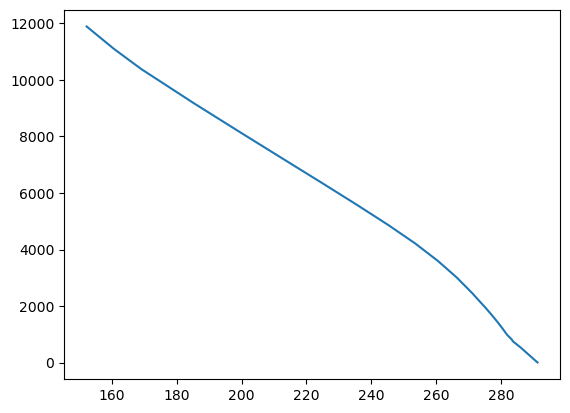

In [782]:
plt.plot(T_parcel_new[156],Z_new[156])

In [754]:
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = np.zeros((rows,cols+1))
for i in range(0,rows):
    q_l_new[i],q_v_parcel_new[i] = profiles.calculate_humidity_profiles_with_entrainment(T_d[i],p_new[i,0],p_new[i],T_parcel_new[i],q_t_parcel_new[i],int(lcl_index[i]))

In [755]:
print(q_v_parcel[20])
print(q_t_parcel_new[1])
print(q_l_new[1])

[8.44919892e-03 8.44919892e-03 8.44919892e-03 8.44919892e-03
 8.35603771e-03 7.99181725e-03 7.60020031e-03 7.20763244e-03
 6.81453966e-03 6.42141863e-03 6.02884675e-03 5.63749320e-03
 5.24813115e-03 4.42005422e-03 3.61199855e-03 2.84779027e-03
 2.14564036e-03 1.52591858e-03 1.00833063e-03 6.06988740e-04
 3.24591441e-04 1.49038463e-04 5.58012681e-05 3.08313676e-05
 1.55734940e-05]
[9.25239269e-03 8.11597332e-03 7.52180349e-03 7.78981671e-03
 7.19997659e-03 5.85147366e-03 5.64977154e-03 5.48383221e-03
 5.28680952e-03 4.66508139e-03 3.73578956e-03 3.30706383e-03
 3.09246336e-03 2.73926137e-03 1.94310327e-03 1.19694485e-03
 5.73683297e-04 4.42769378e-04 3.23367829e-04 1.82183780e-04
 6.52366725e-05 1.78221089e-05 7.10244058e-06 4.76480909e-06
 3.54094664e-06]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


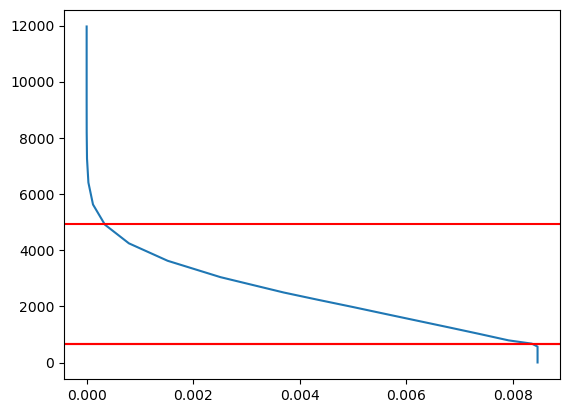

In [756]:
#plt.plot(q_v_new[10],Z_new[10])
plt.plot(q_v_parcel_new[10],Z_new[10])
plt.axhline(Z_new[10,int(lcl_index[10])],color='red')
plt.axhline(Z_new[10,int(LFC_index[10,1])],color='red')
plt.axhline(Z_t[10],color='red')
#plt.plot(q_v_parcel[10],Z_new[10])

Calculating the new parcel virtual temperature profile after considering entrainment 

In [757]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [758]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

Finding the cloud top height and pressure and the resulting cloud depth, again by calling *profiles_and_cloud_heights.py*.

In [759]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

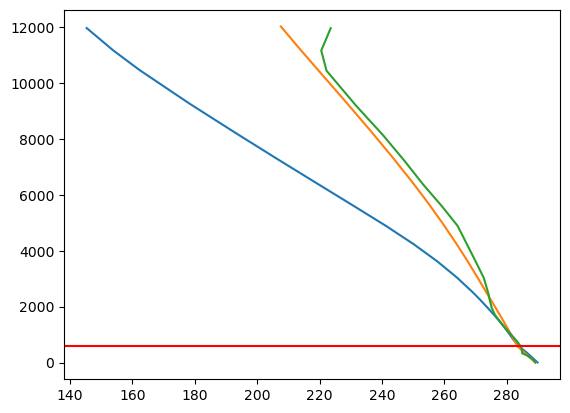

In [760]:
plt.plot(T_parcel_new[10],Z_new[10])
plt.plot(temp_parcel[20],Z_new[20])
plt.plot(my_temp_new[20],Z_new[1])
plt.axhline(y=Z_new[20,int(lcl_index[20])],color='red')
#plt.ylim(0,2000)

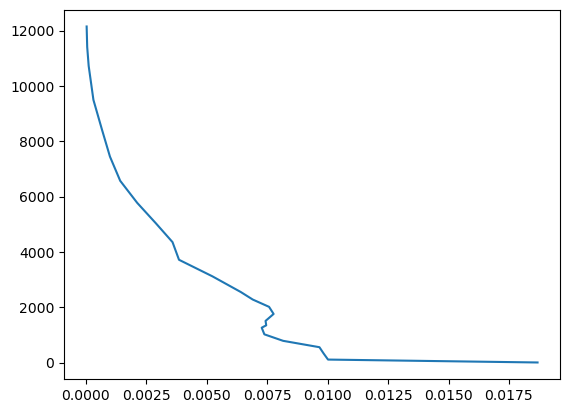

In [761]:
index = np.argmax(Z_t_new)
plt.plot(q_t_parcel_new[index],Z_new[index])

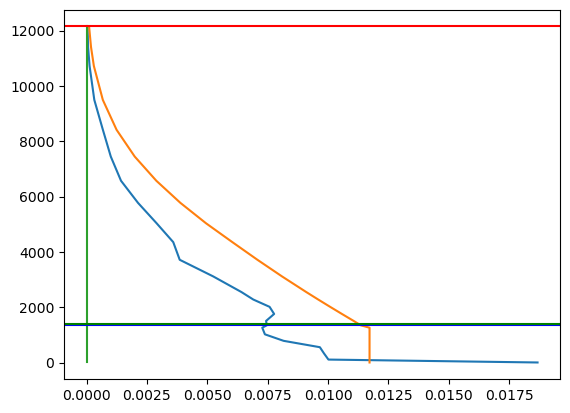

In [762]:
plt.plot(q_t_parcel_new[index],Z_new[index])
#plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_v_parcel_new[index],Z_new[index])
plt.plot(q_l_new[index],Z_new[index])
plt.axhline(y=Z_new[index,int(lcl_index[index])],color='blue')
plt.axhline(y=Z_t[index],color='green')
plt.axhline(y=Z_t_new[index],color='red')

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel updraft velocity profile by calling the *updraft_emmanuel.py*. To do so, we have to first find the index of cloud top height. 

In [763]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)

for i in range(0,rows):
    #print(i)
    if Z_t_new[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new[i] - Z_new[i]) <= 0)

    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(p_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],p_t_new[i],top_index)

[0.01014438]
[0.02739897 0.02817088 0.02898754 0.02985296 0.03077166 0.0317487
 0.03278982]
[0.00628359]
[0.02898754 0.02985296 0.03077166 0.0317487  0.03278982 0.06899287
 0.07410797]
[0.02898754 0.02985296 0.03077166 0.0317487  0.03278982 0.06899287
 0.07410797]
[0.01055022]
[0.01689307 0.02666825 0.02739897 0.02817088]
[0.02033475 0.02739897]
[0.01310255]
[0.007084   0.02739897]
[0.01378425 0.02739897 0.02817088 0.02898754]
[0.00744885 0.02739897 0.02817088 0.02898754]
[0.02276493 0.02817088 0.02898754]
[0.01362008]
[0.01452327]
[0.01763294]
[0.01183088]
[0.01326403]
[0.02247091]
[0.00622712]
[0.02817088 0.02898754 0.02985296 0.03077166 0.0317487  0.03278982]
[0.02817088 0.02898754 0.02985296 0.03077166 0.0317487  0.03278982]
[0.00653446]
[0.01309523]
[0.01836083 0.02597549 0.02666825 0.02739897]
[0.02597549 0.02666825 0.02739897]
[0.00546912]
[0.00612583 0.02531781 0.02597549 0.02666825 0.02739897]
[0.00151844 0.02531781 0.02597549 0.02666825 0.02739897]
[0.02096926 0.02597549 0.02

from constants import R_dry
def w_parcel(p,T_v_moist,T_v_env,lfc_index,p_t,top_index):

    """
    the scheme for calculating the maximum updraft velocity (Emanuel 1991)

    Parameters:
        p: pressure profile  [Pa]"
        T_v_moist: parcel virtual temperature profile [K]"
        T_env: environment virtual temperature profile  [K]"
        lfc_index: index of the LFC
        top_index: index of the top of the cloud

    Returns:
        w_parcel_max: maximum updraft velocity [m/s]
        CAPE: convective available potential energy
    """
    
    if top_index>1 and top_index>int(lfc_index):
    #implementation of the CAPE equation and integration
        delta_ln_p = -np.diff(np.log(p[int(lfc_index):top_index+1]))
        
        buoyancy = R_dry * (T_v_moist - T_v_env)[int(lfc_index):top_index]
        print(buoyancy)
        CAPE = np.sum(buoyancy * delta_ln_p)
        w_parcel_max = np.sqrt(2 * CAPE)
    else:
        w_parcel_max = 0
        CAPE = 0
    return w_parcel_max,CAPE
if Z_t_new[138] == 0:
        top_index = 0
else:
         top_index = np.argmax((Z_t_new[138] - Z_new[138]) <= 0)
print(top_index)
w_parcel(p_new[138],T_v_moist_new[138],T_v_env[138],LFC_index[138,1],p_t_new[138],top_index)

In [764]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

Calculating the state evolution with time. The moisture flux in the cloud system is calculated using the *GB84.py* to find the amount of condensed water, while the outflow is consists of the water amount converted to rain (calculated by *autoconversion_rate.py*) and the cloud droplets caught by the updraft (*top_outflow.py*).

In [765]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    print(i)
    if Z_t_new[i] == 0:
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = GB84_eqs.rho_m(T_s[i],my_temp_new[i,min(top_index,cols-1)],p_s[i],p_t_new[i])

    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = GB84_eqs.flux_2(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index)

    if i<rows-1:
        if X[i]/Z_c_new[i] > 3e-3:        #capping the X values so that they don't abnormally high
            X[i] = 3e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconoversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i] - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        #print(outflow.O_t(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i])
        X[i+1] = max(0,X[i+1])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

#### Rainfall rates

Calculating the precipitation rate in the ground. First, the rate of rainfall exiting the cloud is found by calling *autoconversion_rate.py*. Then, given this rainfall rate, we assume and calculate (*new_rainfall_scheme.py*) a rain droplet size distribution and we estimate the amount that survives evaporation and reaches the ground as precipitation.

In [766]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.cloud_water_autoconoversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

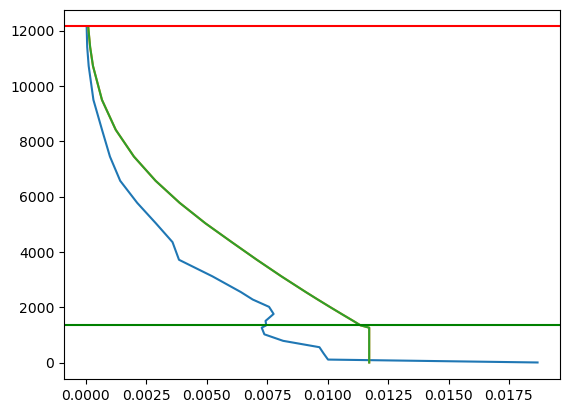

In [767]:
index_max = np.argmax(Z_t_new)
plt.plot(q_v_new[index_max],Z_new[index_max])
plt.plot(q_v_parcel[index_max],Z_new[index_max])
plt.plot(q_v_parcel_new[index_max],Z_new[index_max])
plt.axhline(y=Z_t_new[index_max],color='red')
plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')

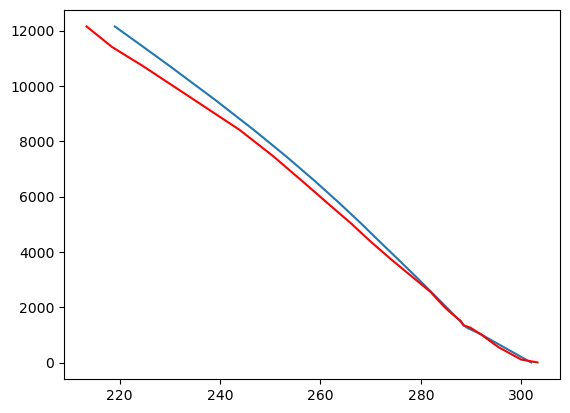

In [768]:
plt.plot(T_v_moist[index_max],Z_new[index_max])
#plt.plot(T_v_moist_new[index_max],Z_new[index_max])
plt.plot(T_v_env[index_max],Z_new[index_max],color='red')

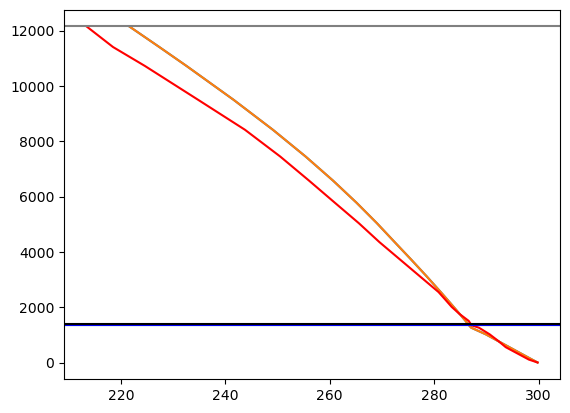

In [769]:
plt.plot(temp_parcel[index_max],Z_new[index_max])
plt.plot(T_parcel_new[index_max],Z_new[index_max])
plt.plot(my_temp_new[index_max],Z_new[index_max],color='red')
plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')
plt.axhline(y=Z_new[index_max,int(lcl_index[index_max])],color='blue')
plt.axhline(y=Z_t[index_max],color='black')
plt.axhline(y=Z_t_new[index_max],color='gray')

In [770]:
def find_lfc_level(T_v_parcel,T_v_env,Z,lcl_index):
    """
    function to find he lfc height

    Parameters:
        T_v_parcel: parcel virtual temperature profile [K]
        T_v_env: environment virtual temperature profile  [K]
        Z: height profile  [m]

    Returns:
        lfc: the lfc height [m]
    """

    #case 1
    if T_v_parcel[lcl_index] > T_v_env[lcl_index]:
        return 'yes', lcl_index  # Case 1: Already buoyant at LCL

    else:
        condition = T_v_parcel[lcl_index:] > T_v_env[lcl_index:]
        if np.any(condition):
            LFC_index = np.argmax(condition) + lcl_index

            # --- CIN: from LCL to LFC where parcel is negatively buoyant ---
            mask_cin = T_v_parcel[lcl_index:LFC_index] < T_v_env[lcl_index:LFC_index]
            if np.any(mask_cin):
                y_cin = g * (T_v_parcel[lcl_index:LFC_index][mask_cin] - T_v_env[lcl_index:LFC_index][mask_cin]) / T_v_parcel[lcl_index:LFC_index][mask_cin]
                Z_cin = Z[lcl_index:LFC_index][mask_cin]
                CIN = -np.trapz(y_cin, Z_cin)
            else:
                CIN = 0.0

            # --- BIN: from LFC upward until buoyancy turns negative ---
            BIN_lower = LFC_index
            condition_bin = T_v_parcel[BIN_lower:] > T_v_env[BIN_lower:]
            if np.any(condition_bin):
                BIN_upper = np.argmax(~condition_bin) + BIN_lower
            else:
                BIN_upper = len(Z)  # buoyancy remains positive until top

            y_bin = g * (T_v_parcel[BIN_lower:BIN_upper] - T_v_env[BIN_lower:BIN_upper]) / T_v_parcel[BIN_lower:BIN_upper]
            Z_bin = Z[BIN_lower:BIN_upper]
            BIN = np.trapz(y_bin, Z_bin)

            # --- Decision ---
            if CIN <= BIN:
                return 'yes', LFC_index  # Case 2: CIN is overcome
            else:
                return 'not reached', 0   # Case 3: CIN too strong
        else:
            return 'no LFC', 0  # Case 4: no crossing of parcel above environment
        
find_lfc_level(T_v_moist[index_max],T_v_env[index_max],Z_new[index_max],int(lcl_index[index_max]))

('yes', 7)

In [771]:
lcl_index[index_max]

7.0

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

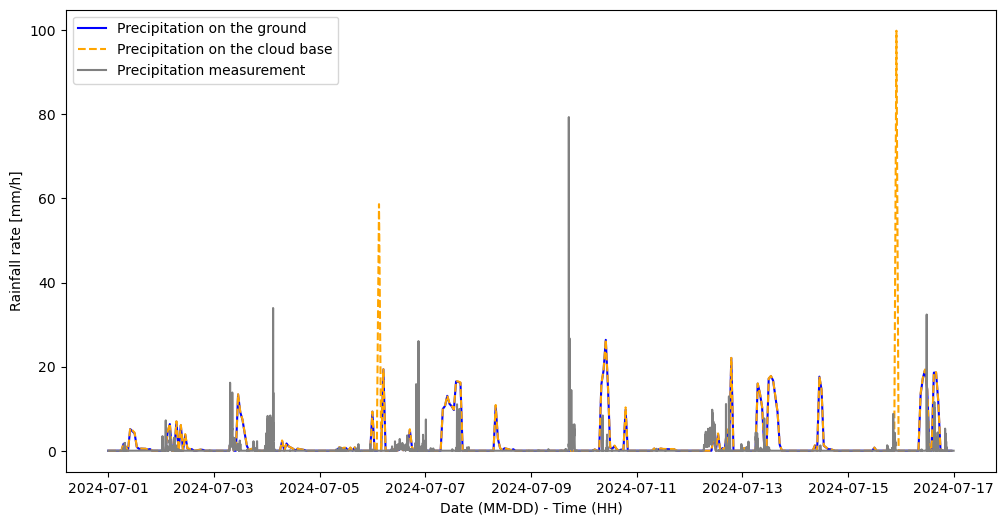

In [772]:
plt.figure(figsize=(12,6))
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

In [781]:
R*3600

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.76532417e+00,
       9.55615024e-01, 0.00000000e+00, 5.40008696e+00, 4.85201308e+00,
       4.31114915e+00, 9.32557406e-01, 4.78533142e-01, 5.32908024e-01,
       4.92224320e-01, 4.80003871e-01, 3.13605218e-01, 4.29973274e-01,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.48200207e+00,
       6.46751579e+00, 0.00000000e+00, 0.00000000e+00, 6.99019864e+00,
       0.00000000e+00, 6.12956168e+00, 0.00000000e+00, 3.93758888e+00,
       5.38043764e-01, 4.38541962e-01, 3.85601958e-01, 8.15912928e-02,
       8.62601137e-02, 1.71942284e-01, 2.67119311e-01, 2.26442414e-01,
       9.00000000e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

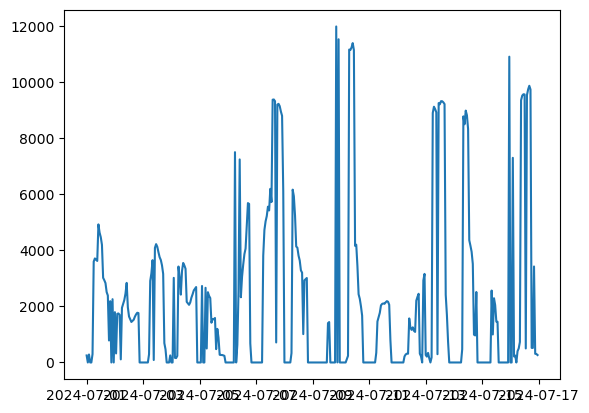

In [774]:
plt.plot(time,Z_t)

#### Virtual Temperature profiles at different times

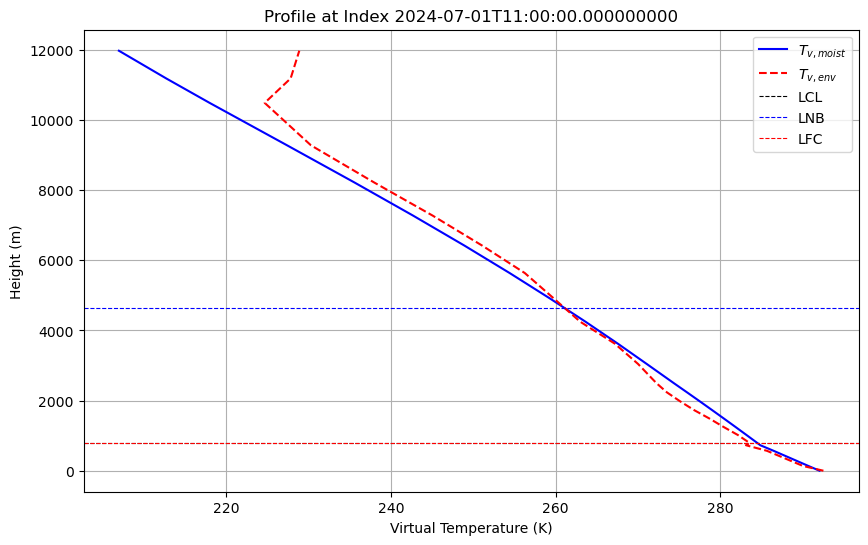

In [775]:
index_2 = 11
fig,ax2 = plt.subplots(figsize=(10,6))
ax2.plot(T_v_moist[index_2], Z_new[index_2], label='$T_{v,moist}$', color='blue')
ax2.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2], 
        label='$T_{v,env}$', color='red', linestyle='--')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.axhline(y=Z[index_2,int(lcl_index[index_2])], color='black', linestyle='--',linewidth='0.8',label='LCL')
ax2.axhline(y=Z_t[index_2], color='blue', linestyle='--',linewidth='0.8',label='LNB')
ax2.axhline(y=Z[index_2,int(LFC_index[index_2,1])], color='red', linestyle='--',linewidth='0.8',label='LFC')
ax2.set_xlabel('Virtual Temperature (K)')
ax2.set_ylabel('Height (m)')
ax2.set_title(f'Profile at Index {time[index_2].values}')
ax2.legend()
ax2.grid(True)

#### Cloud top and base

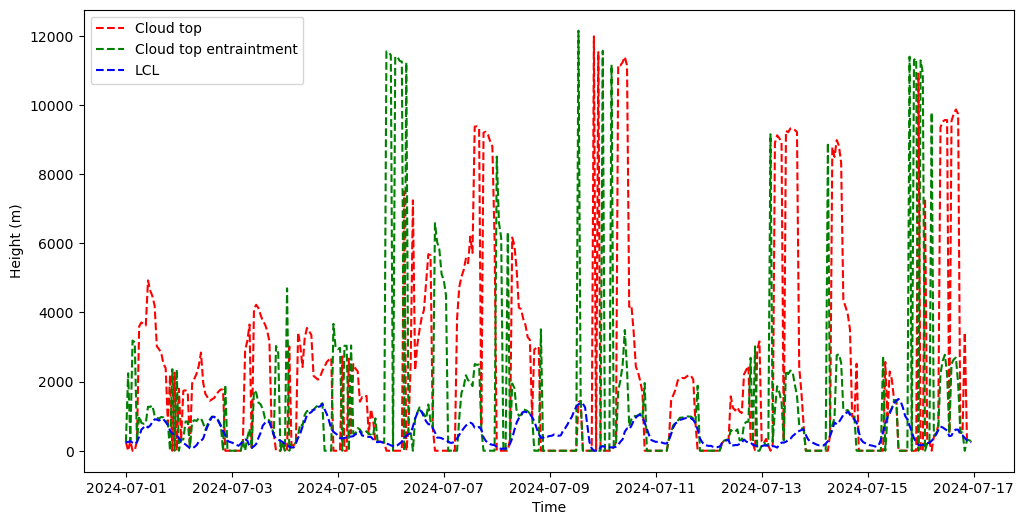

In [776]:
plt.figure(figsize=(12,6))
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_t_new,color='green',linestyle='--',label='Cloud top entraintment')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

#### Updraft velocity

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

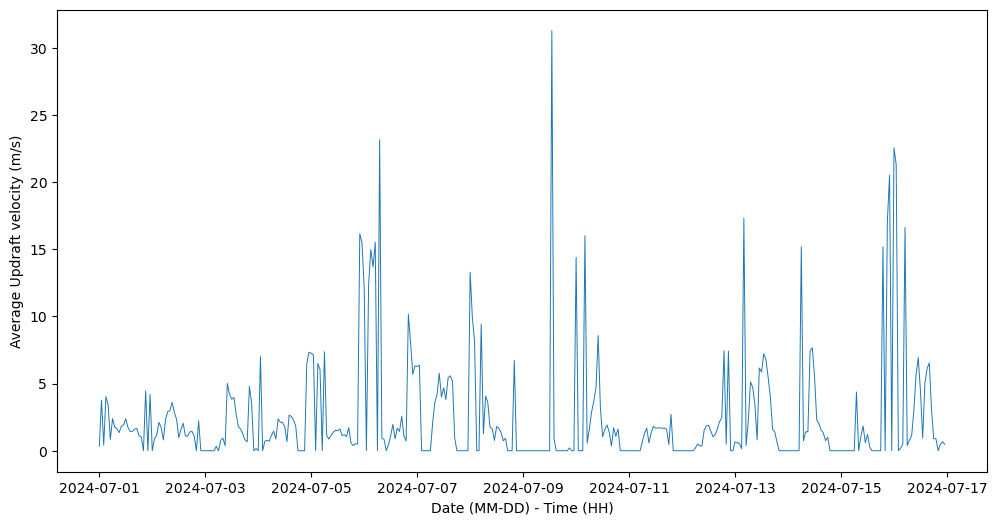

In [777]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

#### LWC and LWP(state)

(0.0, 10.0)

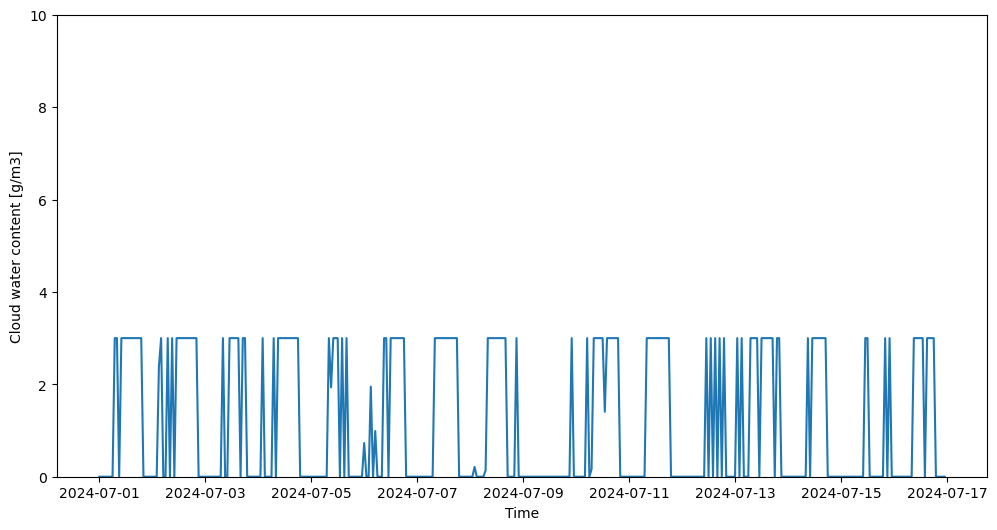

In [778]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c_new*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

Text(0, 0.5, 'Cloud water content [kg/m2]')

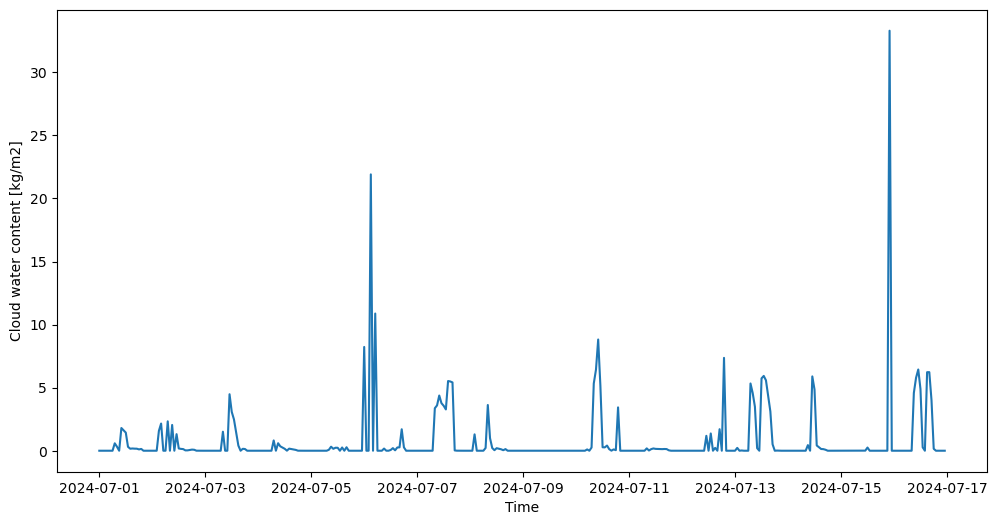

In [779]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

#### Size distribution

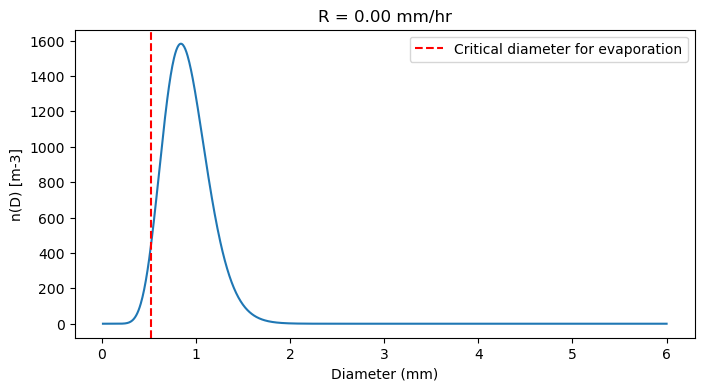

In [780]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()